In [26]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})
from scipy.ndimage import gaussian_filter
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker
from matplotlib.colors import Normalize
import sys
import os
sys.path.append(os.path.abspath('..'))
from scripts.analysis_utils import get_density2d, get_density1d, \
    make_levels, add_colorbar, add_crosshair

In [42]:
data_1 = np.loadtxt('all_real_output.txt')
print(f'Number of pointings: {len(np.unique(data_1[:, 0:2], axis=0))}')
print(f'Number of days: {len(np.unique(data_1[:, 2]))}')
print(f'Total fraction of recovered injections: {(100*len(data_1[data_1[:, -1] > 0.])/len(data_1)):.2f}%')
print(f'Number of injections: {len(data_1)}')

RA_idx = 0
Dec_idx = 1
f_idx = 4
DM_idx = 5
S_idx = 6
FWHM_idx = 7
sigma_idx = 8

TPA_idx = data_1[:, 3].astype('int')
fwhm_array = np.load('../profiles/TPA_fwhm.npy')
fwhm = fwhm_array[TPA_idx]
data_1[:, 7] = fwhm
print('----')
data_all = np.loadtxt('all_harmonics_output.txt')
print(f'Number of pointings: {len(np.unique(data_all[:, 0:2], axis=0))}')
print(f'Number of days: {len(np.unique(data_all[:, 2]))}')
print(f'Total fraction of recovered injections: \
{(100*len(data_all[data_all[:, -1] > 0.])/len(data_all)):.2f}%')
print(f'Number of injections: {len(data_all)}')
TPA_idx = data_all[:, 3].astype('int')
fwhm_array = np.load('../profiles/TPA_fwhm.npy')
fwhm = fwhm_array[TPA_idx]
data_all[:, 7] = fwhm

Number of pointings: 9909
Number of days: 6
Total fraction of recovered injections: 26.27%
Number of injections: 149992
----
Number of pointings: 943
Number of days: 1
Total fraction of recovered injections: 29.79%
Number of injections: 9428


In [87]:
def get_sensitivity(full_data, col, bins, gauss_dev):

    arr_injected, arr_retrieved = get_density1d(full_data, col, bins)

    arr_inj_smooth = gaussian_filter(arr_injected, gauss_dev)
    arr_ret_smooth = gaussian_filter(arr_retrieved, gauss_dev)

    arr_inj_p_smooth = arr_inj_smooth / np.sum(arr_inj_smooth)
    arr_ret_p_smooth = arr_ret_smooth / arr_inj_smooth

    arr_ret_p = arr_retrieved / arr_injected
    
    nan_mask = np.isnan(arr_ret_p)
    x = np.arange(len(arr_ret_p))
    arr_ret_p[nan_mask] = np.interp(x[nan_mask], x[~nan_mask], arr_ret_p[~nan_mask])

    arr_ret_p_smooth[np.isnan(arr_ret_p_smooth)] = 0.

    return arr_inj_p_smooth, arr_ret_p, arr_ret_p_smooth

In [110]:
f_bins= np.logspace(-3, 2.7, 101)
f_inj_p_smooth_1, f_ret_p_1, f_ret_p_smooth_1 = get_sensitivity(
    full_data = data_1, 
    col = f_idx, 
    bins = f_bins, 
    gauss_dev = 5
)
f_inj_p_smooth_all, f_ret_p_all, f_ret_p_smooth_all = get_sensitivity(
    full_data = data_all, 
    col = f_idx, 
    bins = f_bins, 
    gauss_dev = 5
)

DM_bins = np.linspace(0, 400, 50)
DM_inj_p_smooth_1, DM_ret_p_1, DM_ret_p_smooth_1 = get_sensitivity(
    full_data = data_1,
    col = DM_idx,
    bins = DM_bins,
    gauss_dev = 12
)
DM_inj_p_smooth_all, DM_ret_p_all, DM_ret_p_smooth_all = get_sensitivity(
    full_data = data_all,
    col = DM_idx,
    bins = DM_bins,
    gauss_dev = 12
)

S_bins = np.logspace(-2, 1, 101)
S_inj_p_smooth_1, S_ret_p_1, S_ret_p_smooth_1 = get_sensitivity(
    full_data = data_1,
    col = S_idx,
    bins = S_bins,
    gauss_dev = 5
)
S_inj_p_smooth_all, S_ret_p_all, S_ret_p_smooth_all = get_sensitivity(
    full_data = data_all,
    col = S_idx,
    bins = S_bins,
    gauss_dev = 5
)

fwhm_bins = np.logspace(np.log10(min(fwhm)), -0.95, 101)
fwhm_inj_p_smooth_1, fwhm_ret_p_1, fwhm_ret_p_smooth_1 = get_sensitivity(
    full_data = data_1,
    col = FWHM_idx,
    bins = fwhm_bins,
    gauss_dev = 10,
)
fwhm_inj_p_smooth_all, fwhm_ret_p_all, fwhm_ret_p_smooth_all = get_sensitivity(
    full_data = data_all,
    col = FWHM_idx,
    bins = fwhm_bins,
    gauss_dev = 10,
)

RA_bins = np.linspace(0, 360, 101)
RA_inj_p_smooth_1, RA_ret_p_1, RA_ret_p_smooth_1 = get_sensitivity(
    full_data = data_1,
    col = RA_idx,
    bins = RA_bins,
    gauss_dev = 5,
)
RA_inj_p_smooth_all, RA_ret_p_all, RA_ret_p_smooth_all = get_sensitivity(
    full_data = data_all,
    col = RA_idx,
    bins = RA_bins,
    gauss_dev = 5,
)

Dec_bins = np.linspace(min(data_1[:, Dec_idx]), max(data_1[:, Dec_idx]), 101)
Dec_inj_p_smooth_1, Dec_ret_p_1, Dec_ret_p_smooth_1 = get_sensitivity(
    full_data = data_1,
    col = Dec_idx,
    bins = Dec_bins,
    gauss_dev = 20,
)
Dec_inj_p_smooth_all, Dec_ret_p_all, Dec_ret_p_smooth_all = get_sensitivity(
    full_data = data_all,
    col = Dec_idx,
    bins = Dec_bins,
    gauss_dev = 20,
)

/tmp/ipykernel_2399874/2550364166.py:11: RuntimeWarning: invalid value encountered in divide
  arr_ret_p = arr_retrieved / arr_injected
/tmp/ipykernel_2399874/2550364166.py:9: RuntimeWarning: invalid value encountered in divide
  arr_ret_p_smooth = arr_ret_smooth / arr_inj_smooth


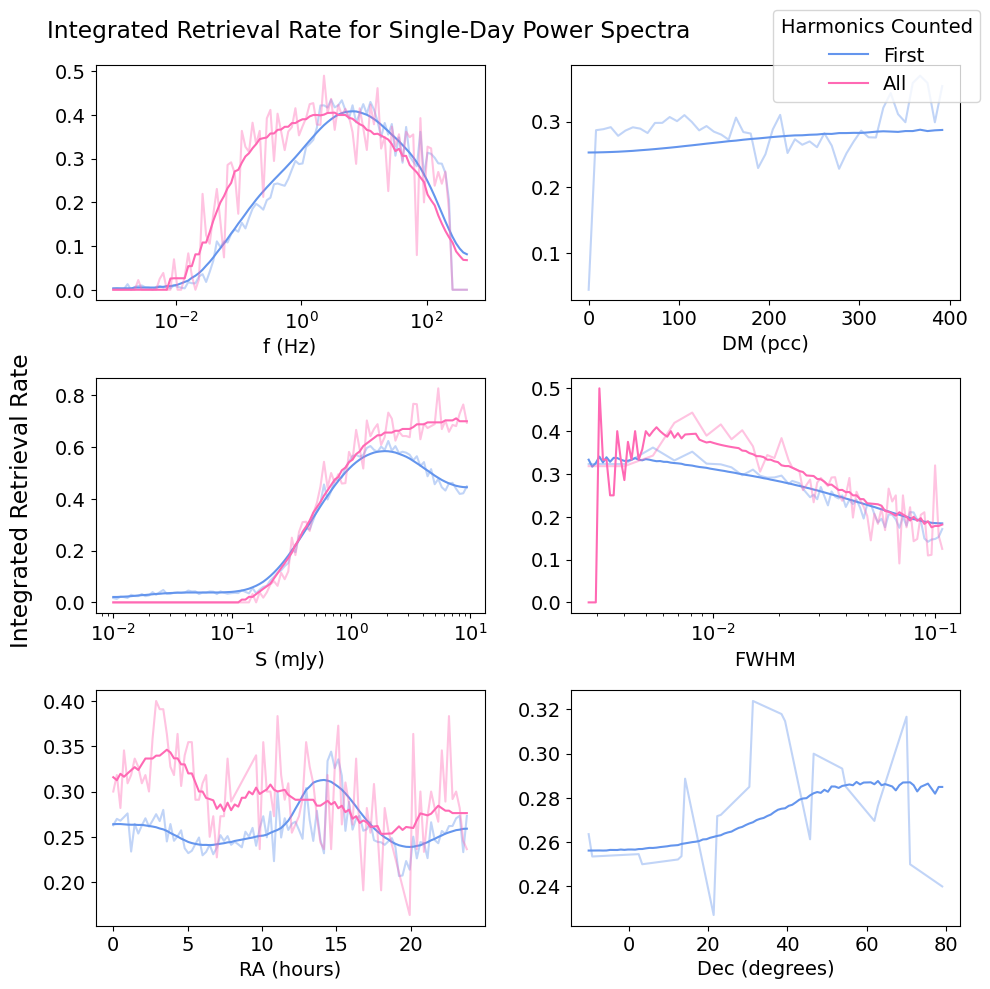

In [127]:
fig, ax = plt.subplots(3, 2, figsize=(10, 10))
ax = ax.flatten()
ax[0].plot(f_bins[:-1], f_ret_p_smooth_1, color='cornflowerblue', label='First')
ax[0].plot(f_bins[:-1], f_ret_p_1, alpha=0.4, color='cornflowerblue')
ax[0].plot(f_bins[:-1], f_ret_p_smooth_all, color='hotpink', label='All')
ax[0].plot(f_bins[:-1], f_ret_p_all, alpha=0.4, color='hotpink')
ax[0].set_xscale('log')
ax[0].set_xlabel('f (Hz)')

ax[1].plot(DM_bins[:-1], DM_ret_p_smooth_1, color='cornflowerblue', label='First')
ax[1].plot(DM_bins[:-1], DM_ret_p_1, alpha=0.4, color='cornflowerblue')
#ax[1].plot(DM_bins[:-1], DM_ret_p_smooth_all, color='hotpink', label='All')
#ax[1].plot(DM_bins[:-1], DM_ret_p_all, alpha=0.4, color='hotpink')
ax[1].set_xlabel('DM (pcc)')

ax[2].plot(S_bins[:-1], S_ret_p_smooth_1, color='cornflowerblue', label='First')
ax[2].plot(S_bins[:-1], S_ret_p_1, alpha=0.4, color='cornflowerblue')
ax[2].plot(S_bins[:-1], S_ret_p_smooth_all, color='hotpink', label='All')
ax[2].plot(S_bins[:-1], S_ret_p_all, alpha=0.4, color='hotpink')
ax[2].set_xscale('log')
ax[2].set_xlabel('S (mJy)')

ax[3].plot(fwhm_bins[:-1], fwhm_ret_p_smooth_1, color='cornflowerblue', label='First')
ax[3].plot(fwhm_bins[:-1], fwhm_ret_p_1, alpha=0.4, color='cornflowerblue')
ax[3].plot(fwhm_bins[:-1], fwhm_ret_p_smooth_all, color='hotpink', label='All')
ax[3].plot(fwhm_bins[:-1], fwhm_ret_p_all, alpha=0.4, color='hotpink')
ax[3].set_xscale('log')
ax[3].set_xlabel('FWHM')

ax[4].plot(RA_bins[:-1] / 15, RA_ret_p_smooth_1, color='cornflowerblue', label='First')
ax[4].plot(RA_bins[:-1] / 15, RA_ret_p_1, alpha=0.4, color='cornflowerblue')
ax[4].plot(RA_bins[:-1] / 15, RA_ret_p_smooth_all, color='hotpink', label='All')
ax[4].plot(RA_bins[:-1] / 15, RA_ret_p_all, alpha=0.4, color='hotpink')
ax[4].set_xlabel('RA (hours)')

ax[5].plot(Dec_bins[:-1], Dec_ret_p_smooth_1, color='cornflowerblue', label='First')
ax[5].plot(Dec_bins[:-1], Dec_ret_p_1, alpha=0.4, color='cornflowerblue')
#ax[5].plot(Dec_bins[:-1], Dec_ret_p_smooth_all, color='hotpink', label='All')
#ax[5].plot(Dec_bins[:-1], Dec_ret_p_all, alpha=0.4, color='hotpink')
ax[5].set_xlabel('Dec (degrees)')

fig.suptitle('Integrated Retrieval Rate for Single-Day Power Spectra', horizontalalignment='right', x = 0.7)
fig.supylabel('Integrated Retrieval Rate')
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Harmonics Counted', loc='upper right',
           bbox_to_anchor=(1.0, 1.0), bbox_transform=fig.transFigure)
plt.tight_layout()

In [ ]:

f_injected, f_retrieved = get_density1d(data_1, 4, f_bins1d)
f_inj_smooth = gaussian_filter(f_injected, 5)
f_inj_p = f_inj_smooth / np.sum(f_inj_smooth)
f_ret_smooth = gaussian_filter(f_retrieved, 5)
f_ret_p = f_ret_smooth / f_inj_smooth

DM_bins1d = np.linspace(0, 700, 100)
DM_injected, DM_retrieved = get_density1d(data_1, 5, DM_bins1d)
DM_inj_smooth = gaussian_filter(DM_injected, 30)
DM_inj_p = DM_inj_smooth / np.sum(DM_inj_smooth)
DM_ret_smooth = gaussian_filter(DM_retrieved, 30)
DM_ret_p = DM_ret_smooth / DM_inj_smooth
DM_ret_p[np.isnan(DM_ret_p)] = 0

S_bins = np.logspace(-2, 1, 51)
S_injected, S_retrieved = get_density1d(data_1, 6, S_bins)
S_inj_smooth = gaussian_filter(S_injected, S_dev)
S_inj_p = S_inj_smooth / np.sum(S_inj_smooth)
S_ret_smooth = gaussian_filter(S_retrieved, S_dev)
S_ret_p = S_ret_smooth / S_inj_smooth

fwhm_bins1d = np.logspace(np.log10(min(fwhm)), -0.95, 101)
fwhm_injected, fwhm_retrieved = get_density1d(data_1, 7, fwhm_bins1d)
fwhm_inj_smooth = gaussian_filter(fwhm_injected, 15)
fwhm_inj_p = fwhm_inj_smooth / np.sum(fwhm_inj_smooth)
fwhm_ret_smooth = gaussian_filter(fwhm_retrieved, 15)
fwhm_ret_p = fwhm_ret_smooth / fwhm_inj_smooth

RA_bins1d = np.linspace(0, 360, 100)
ra_injected, ra_retrieved = get_density1d(data_1, 0, RA_bins1d)
ra_inj_smooth = gaussian_filter(ra_injected, 10)
ra_inj_p = ra_inj_smooth / np.sum(ra_inj_smooth)
ra_ret_smooth = gaussian_filter(ra_retrieved, 10)
ra_ret_p = ra_ret_smooth / ra_inj_smooth

Dec_bins1d = np.linspace(min(Dec), max(Dec), 70)
dec_injected, dec_retrieved = get_density1d(data_1, 1, Dec_bins1d)
dec_inj_smooth = gaussian_filter(dec_injected, 20)
dec_inj_p = dec_inj_smooth / np.sum(dec_inj_smooth)
dec_ret_smooth = gaussian_filter(dec_retrieved, 20)
dec_ret_p = dec_ret_smooth / dec_inj_smooth

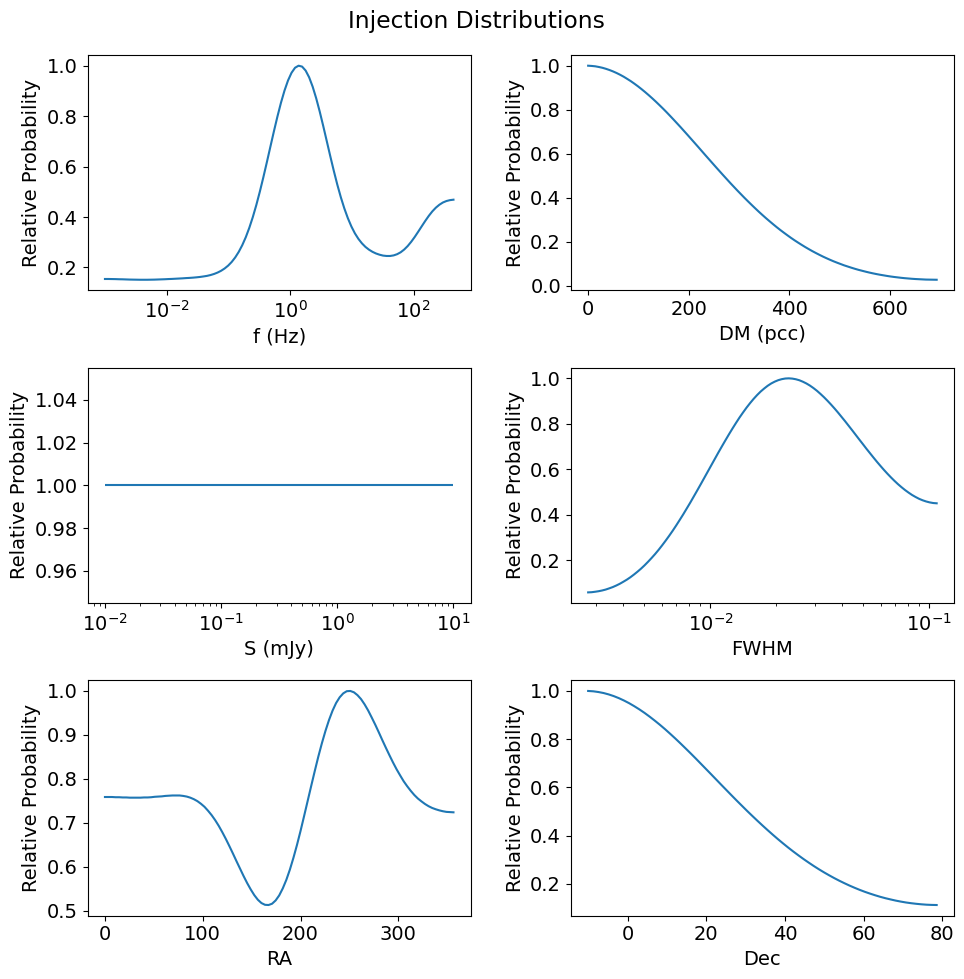

In [30]:
fig, ax = plt.subplots(3, 2, figsize = (10, 10))
ax = ax.flatten()

ax[0].plot(f_bins1d[:-1], f_inj_p/np.max(f_inj_p))
ax[0].set_xscale('log')
ax[0].set_xlabel('f (Hz)')
ax[0].set_ylabel('Relative Probability')

ax[1].plot(DM_bins1d[:-1], DM_inj_p/np.max(DM_inj_p))
ax[1].set_xlabel('DM (pcc)')
ax[1].set_ylabel('Relative Probability')

ax[2].hlines(1, S_bins[0], S_bins[-1])
ax[2].set_xscale('log')
ax[2].set_xlabel('S (mJy)')
ax[2].set_ylabel('Relative Probability')

ax[3].plot(fwhm_bins1d[:-1], fwhm_inj_p/np.max(fwhm_inj_p))
ax[3].set_xscale('log')
ax[3].set_xlabel('FWHM')
ax[3].set_ylabel('Relative Probability')

ax[4].plot(RA_bins1d[:-1], ra_inj_p/np.max(ra_inj_p))
ax[4].set_xlabel('RA')
ax[4].set_ylabel('Relative Probability')

ax[5].plot(Dec_bins1d[:-1], dec_inj_p/np.max(dec_inj_p))
ax[5].set_xlabel('Dec')
ax[5].set_ylabel('Relative Probability')

fig.suptitle('Injection Distributions')
plt.tight_layout()

In [ ]:
f_bins1d = np.logspace(np.log10(min(f)), np.log10(max(f)), 101)
f_injected, f_retrieved = get_density1d(data_1, 4, f_bins1d)
f_inj_smooth = gaussian_filter(f_injected, 5)
f_inj_p = f_inj_smooth / np.sum(f_inj_smooth)
f_ret_smooth = gaussian_filter(f_retrieved, 5)
f_ret_p = f_ret_smooth / f_inj_smooth

DM_bins1d = np.linspace(0, 700, 100)
DM_injected, DM_retrieved = get_density1d(data_1, 5, DM_bins1d)
DM_inj_smooth = gaussian_filter(DM_injected, 30)
DM_inj_p = DM_inj_smooth / np.sum(DM_inj_smooth)
DM_ret_smooth = gaussian_filter(DM_retrieved, 30)
DM_ret_p = DM_ret_smooth / DM_inj_smooth
DM_ret_p[np.isnan(DM_ret_p)] = 0

S_injected, S_retrieved = get_density1d(data_1, 6, S_bins)
S_inj_smooth = gaussian_filter(S_injected, S_dev)
S_inj_p = S_inj_smooth / np.sum(S_inj_smooth)
S_ret_smooth = gaussian_filter(S_retrieved, S_dev)
S_ret_p = S_ret_smooth / S_inj_smooth

fwhm_bins1d = np.logspace(np.log10(min(fwhm)), -0.95, 51)
fwhm_injected, fwhm_retrieved = get_density1d(data_1, 7, fwhm_bins1d)
fwhm_inj_smooth = gaussian_filter(fwhm_injected, 15)
fwhm_inj_p = fwhm_inj_smooth / np.sum(fwhm_inj_smooth)
fwhm_ret_smooth = gaussian_filter(fwhm_retrieved, 15)
fwhm_ret_p = fwhm_ret_smooth / fwhm_inj_smooth

RA_bins1d = np.linspace(0, 360, 100)
ra_injected, ra_retrieved = get_density1d(data_1, 0, RA_bins1d)
ra_inj_smooth = gaussian_filter(ra_injected, 10)
ra_inj_p = ra_inj_smooth / np.sum(ra_inj_smooth)
ra_ret_smooth = gaussian_filter(ra_retrieved, 10)
ra_ret_p = ra_ret_smooth / ra_inj_smooth

Dec_bins1d = np.linspace(min(Dec), max(Dec), 70)
dec_injected, dec_retrieved = get_density1d(data_1, 1, Dec_bins1d)
dec_inj_smooth = gaussian_filter(dec_injected, 20)
dec_inj_p = dec_inj_smooth / np.sum(dec_inj_smooth)
dec_ret_smooth = gaussian_filter(dec_retrieved, 20)
dec_ret_p = dec_ret_smooth / dec_inj_smooth

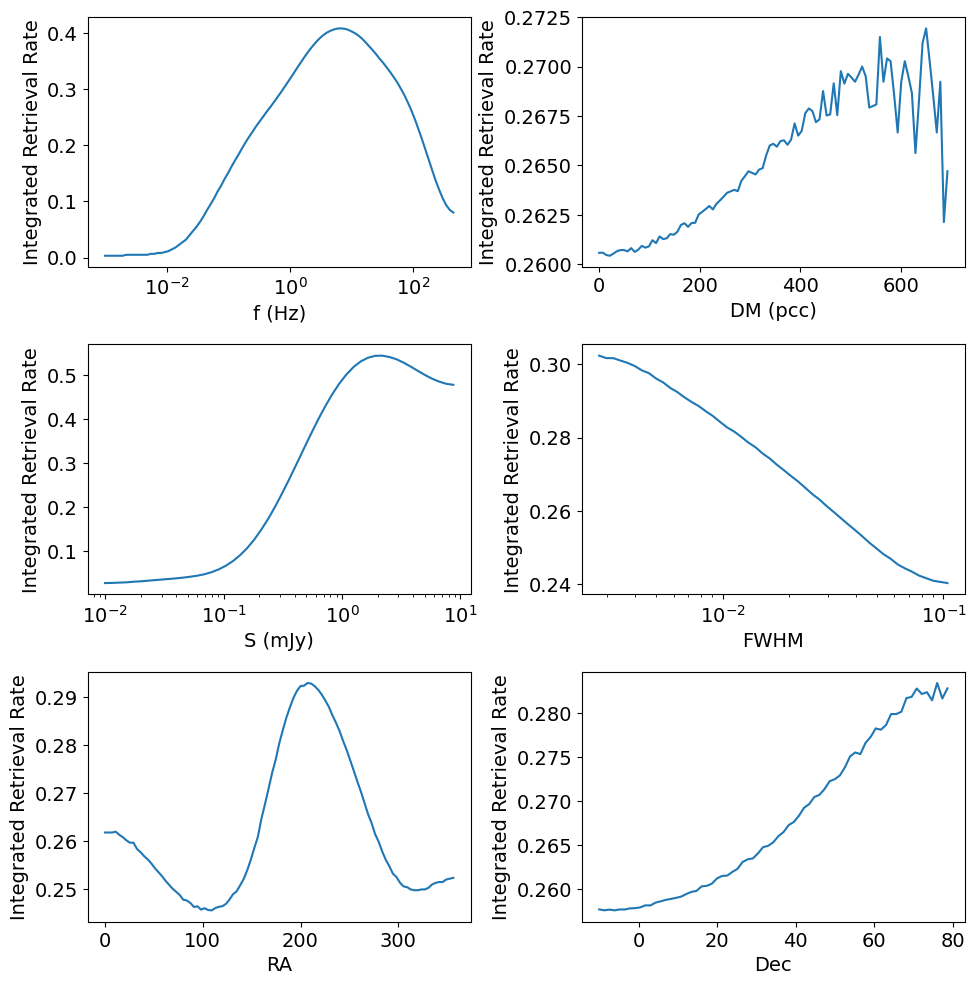

In [32]:
fig, ax = plt.subplots(3, 2, figsize = (10, 10))
ax = ax.flatten()

ax[0].plot(f_bins1d[:-1], f_ret_p)
ax[0].set_xscale('log')
ax[0].set_xlabel('f (Hz)')
ax[0].set_ylabel('Integrated Retrieval Rate')

ax[1].plot(DM_bins1d[:-1], DM_ret_p)
ax[1].set_xlabel('DM (pcc)')
ax[1].set_ylabel('Integrated Retrieval Rate')

ax[2].plot(S_bins[:-1], S_ret_p)
ax[2].set_xscale('log')
ax[2].set_xlabel('S (mJy)')
ax[2].set_ylabel('Integrated Retrieval Rate')

ax[3].plot(fwhm_bins1d[:-1], fwhm_ret_p)
ax[3].set_xscale('log')
ax[3].set_xlabel('FWHM')
ax[3].set_ylabel('Integrated Retrieval Rate')

ax[4].plot(RA_bins1d[:-1], ra_ret_p)
ax[4].set_xlabel('RA')
ax[4].set_ylabel('Integrated Retrieval Rate')

ax[5].plot(Dec_bins1d[:-1], dec_ret_p)
ax[5].set_xlabel('Dec')
ax[5].set_ylabel('Integrated Retrieval Rate')

plt.tight_layout()